In [6]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 150

data = {
    'Age': np.random.randint(18, 65, n),
    'TenureMonths': np.random.randint(1, 60, n),
    'MonthlySpend': np.random.randint(300, 2000, n),
    'HasComplaints': np.random.choice([0, 1], n),
    'SupportCalls': np.random.randint(0, 10, n),
}

data['Churn'] = (
    (data['HasComplaints'] & (data['TenureMonths'] < 12)) |
    (data['MonthlySpend'] > 1500)
).astype(int)

df = pd.DataFrame(data)

df.to_csv("churn_project.csv", index=False)

df.head()

,Age,TenureMonths,MonthlySpend,HasComplaints,SupportCalls,Churn
0,56,30,1316,1,7,0
1,46,37,1895,1,6,1
2,32,23,1180,1,1,0
3,60,39,301,1,0,0
4,25,45,1196,0,3,0


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

ridge_model = RidgeClassifier(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_preds = ridge_model.predict(X_test_scaled)

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(name, y_true, y_pred):
    print("\n===== ", name, " =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("Ridge Classifier", y_test, ridge_preds)


=====  Random Forest  =====
Accuracy: 1.0
Confusion Matrix:
 [[22  0]
 [ 0  8]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


=====  Ridge Classifier  =====
Accuracy: 0.8333333333333334
Confusion Matrix:
 [[18  4]
 [ 1  7]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.82      0.88        22
           1       0.64      0.88      0.74         8

    accuracy                           0.83        30
   macro avg       0.79      0.85      0.81        30
weighted avg       0.86      0.83      0.84        30



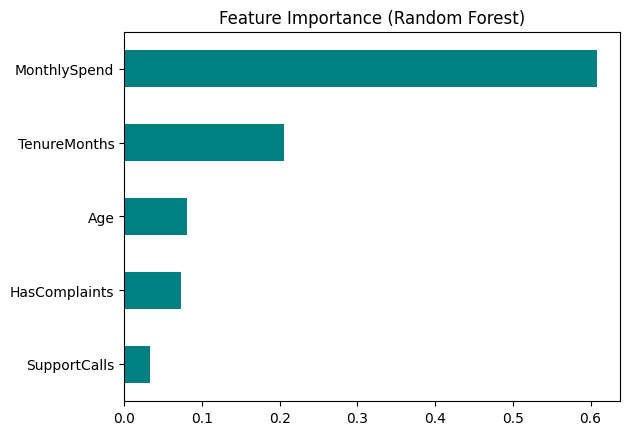

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance (Random Forest)")
plt.show()

C:\Users\sansk\AppData\Local\Temp\ipykernel_6340\241881684.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['lightblue', 'orange'])


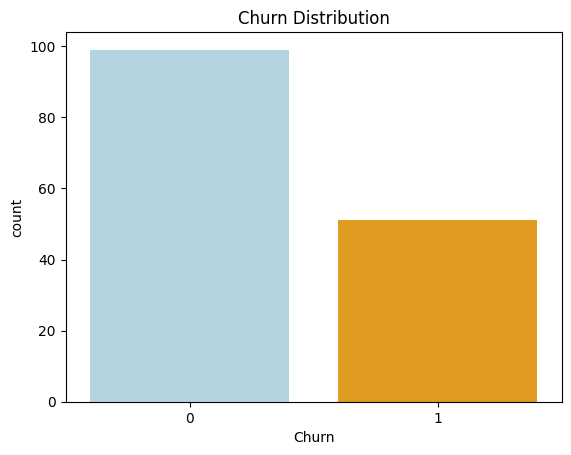

In [16]:
sns.countplot(x='Churn', data=df, palette=['lightblue', 'orange'])
plt.title("Churn Distribution")
plt.show()

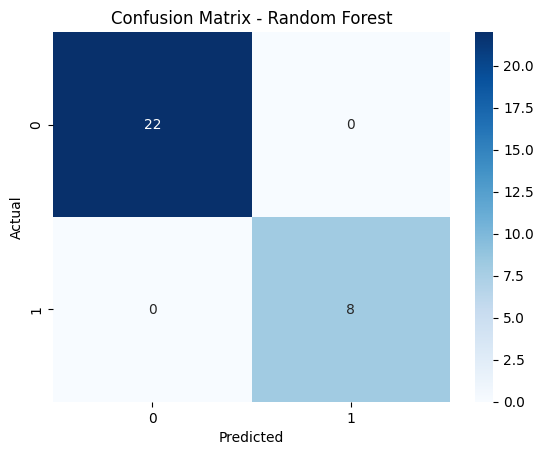

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()